In [1]:
# Importing core libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
# Load Dataset

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Checking for target variable imbalance

In [7]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
df['Churn'].value_counts(normalize=True).round(3)

Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64

### Data Cleaning and Preprocessing

In [9]:
# make a copy of the original data

data = df.copy()

data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [10]:
# total missing data after conversion

data['TotalCharges'].isnull().sum()

11

In [11]:
# Inspecting all the rows before making changes

data[data['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [12]:
# replacing NaN values in TotalCharges column to 0, as they are new customers and no charges are accumulated yet.

data['TotalCharges'] = data['TotalCharges'].fillna(0)

In [13]:
data.isnull().sum().sum()

0

In [14]:
# Dropping customerID column

data = data.drop('customerID',axis=1)

In [15]:
data.shape

(7043, 20)

In [16]:
# replacing values in the Columns uses No internet service/No phone service to No

service_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in service_cols:
    data[col] = data[col].replace({'No internet service': 'No',
                                    'No phone service': 'No'})

In [17]:
# Mapping target to 0/1

data['Churn'] = data['Churn'].map({'No': 0, 'Yes': 1})

### Exploratory Data Analysis

In [18]:
!pip install --upgrade seaborn


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


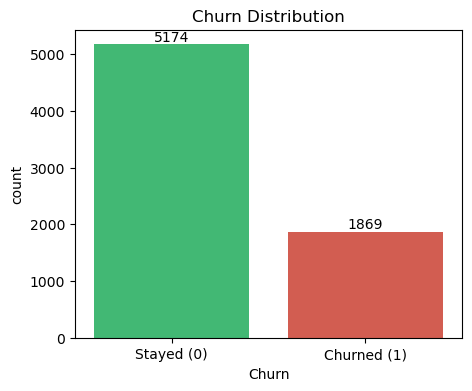

Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


In [19]:
plt.figure(figsize=(5, 4))
ax = sns.countplot(x='Churn', data=data, palette=['#2ecc71', '#e74c3c'])
ax.set_xticklabels(['Stayed (0)', 'Churned (1)'])
plt.title('Churn Distribution')

# Annotate counts
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()

print(data['Churn'].value_counts(normalize=True).round(3))

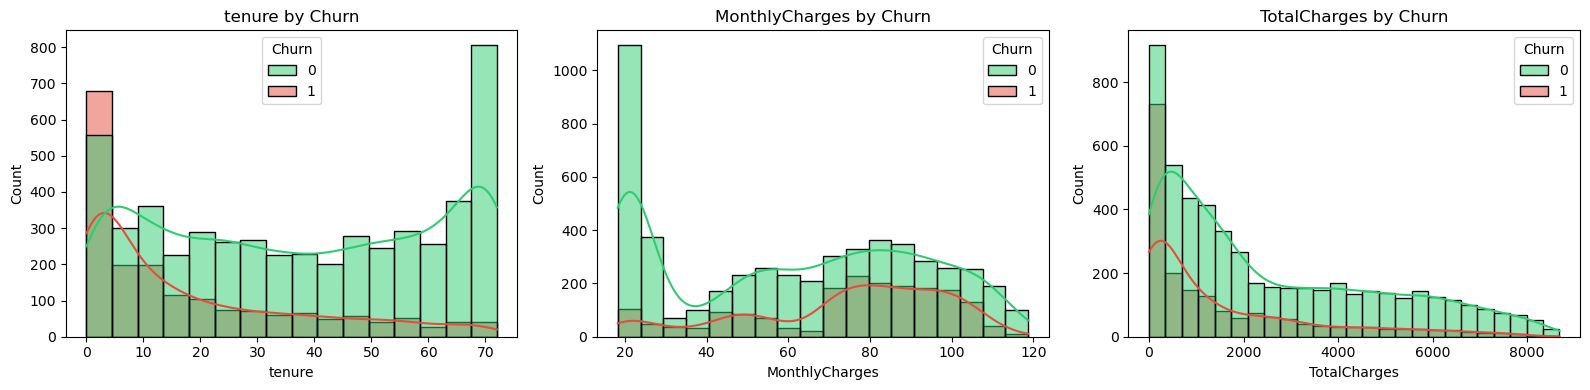

In [20]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(num_cols):
    sns.histplot(data=data, x=col, hue='Churn', kde=True,
                 palette=['#2ecc71', '#e74c3c'], ax=axes[i])
    axes[i].set_title(f'{col} by Churn')
plt.tight_layout()
plt.show()

In [21]:
data.groupby('Churn')[num_cols].mean().round(2)

,tenure,MonthlyCharges,TotalCharges
Churn,,,
0,37.57,61.27,2549.91
1,17.98,74.44,1531.80


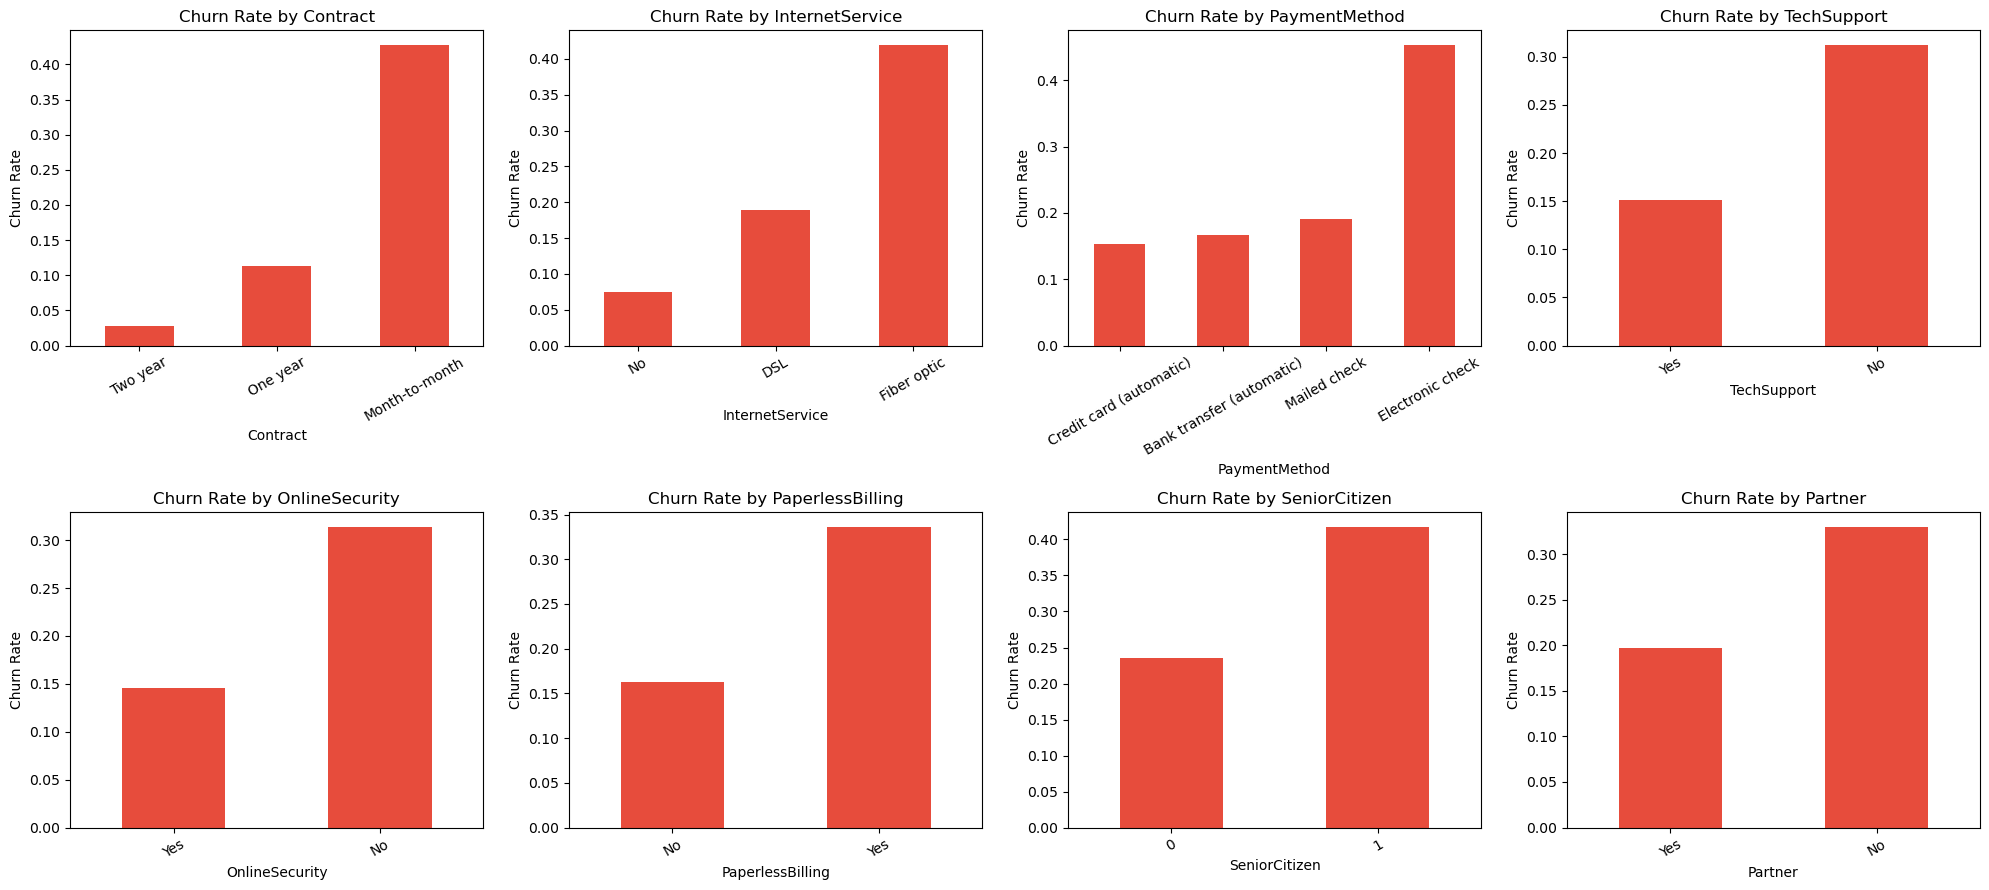

In [22]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport',
            'OnlineSecurity', 'PaperlessBilling', 'SeniorCitizen', 'Partner']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for i, col in enumerate(cat_cols):
    ax = axes[i // 4, i % 4]
    # Mean of Churn (0/1) per category = churn rate
    churn_rate = data.groupby(col)['Churn'].mean().sort_values()
    churn_rate.plot(kind='bar', ax=ax, color='#e74c3c')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

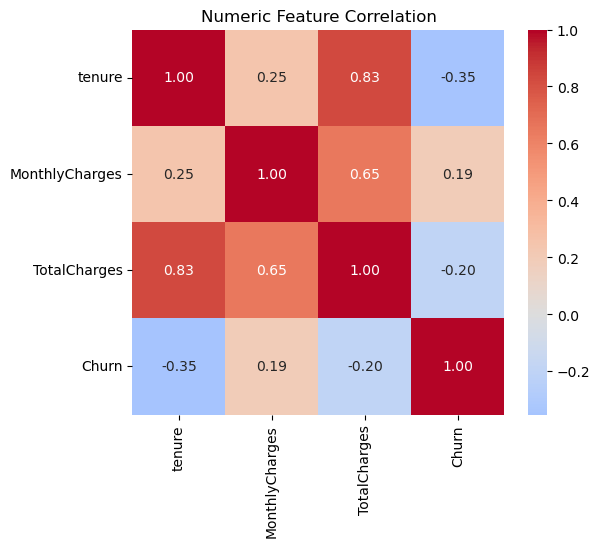

In [23]:
plt.figure(figsize=(6, 5))
corr = data[num_cols + ['Churn']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Numeric Feature Correlation')
plt.show()

In [24]:
# Making a new copy of EDA performed data

df_fe = data.copy()

In [25]:
df_fe['tenure_group'] = pd.cut(
    df_fe['tenure'],
    bins=[0, 12, 24, 48, 60, 72],
    labels=['0-1yr', '1-2yr', '2-4yr', '4-5yr', '5-6yr'],
    include_lowest=True
)

print(df_fe['tenure_group'].value_counts())

tenure_group
0-1yr    2186
2-4yr    1594
5-6yr    1407
1-2yr    1024
4-5yr     832
Name: count, dtype: int64


In [26]:
service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']

df_fe['num_services'] = (df_fe[service_cols] == 'Yes').sum(axis=1)

df_fe['num_services'] += (df_fe['InternetService'] != 'No').astype(int)

print(df_fe['num_services'].value_counts().sort_index())

num_services
1    1264
2     859
3     846
4     965
5     922
6     908
7     676
8     395
9     208
Name: count, dtype: int64


In [27]:
df_fe['avg_charge_per_month'] = df_fe['TotalCharges'] / (df_fe['tenure'] + 1)

df_fe[['tenure', 'TotalCharges', 'avg_charge_per_month']].head()

,tenure,TotalCharges,avg_charge_per_month
0,1,29.85,14.925000
1,34,1889.50,53.985714
2,2,108.15,36.050000
3,45,1840.75,40.016304
4,2,151.65,50.550000


In [28]:
# Columns that are cleanly Yes/No or have two values -> map to 1/0
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    df_fe[col] = df_fe[col].map({'Yes': 1, 'No': 0})

# gender is its own binary
df_fe['gender'] = df_fe['gender'].map({'Male': 1, 'Female': 0})

# SeniorCitizen is already 0/1
df_fe[binary_cols + ['gender']].head()

,Partner,Dependents,PhoneService,PaperlessBilling,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,gender
0,1,0,0,1,0,0,1,0,0,0,0,0
1,0,0,1,0,0,1,0,1,0,0,0,1
2,0,0,1,1,0,1,1,0,0,0,0,1
3,0,0,0,0,0,1,0,1,1,0,0,1
4,0,0,1,1,0,0,0,0,0,0,0,0


In [29]:
multi_cat_cols = ['InternetService', 'Contract', 'PaymentMethod', 'tenure_group']

df_fe = pd.get_dummies(df_fe, columns=multi_cat_cols, drop_first=True)

bool_cols = df_fe.select_dtypes('bool').columns
df_fe[bool_cols] = df_fe[bool_cols].astype(int)

In [30]:
print("Shape after encoding:", df_fe.shape)

Shape after encoding: (7043, 30)


### Train/Test split

In [31]:
X = df_fe.drop('Churn', axis=1)
y = df_fe['Churn']

print("Features:", X.shape)
print("Target distribution:\n", y.value_counts(normalize=True).round(3))

Features: (7043, 29)
Target distribution:
 Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          
)

In [33]:
from sklearn.preprocessing import StandardScaler

num_features = ['tenure', 'MonthlyCharges', 'TotalCharges',
                'num_services', 'avg_charge_per_month']

scaler = StandardScaler()

X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features]  = scaler.transform(X_test[num_features])

X_train[num_features].describe().round(2)

,tenure,MonthlyCharges,TotalCharges,num_services,avg_charge_per_month
count,5634.00,5634.00,5634.00,5634.00,5634.00
mean,-0.00,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00
min,-1.32,-1.54,-1.01,-1.36,-1.93
25%,-0.96,-0.97,-0.83,-0.93,-1.08
50%,-0.14,0.18,-0.40,-0.07,0.07
75%,0.92,0.83,0.67,0.79,0.85
max,1.61,1.79,2.80,2.08,1.95


In [34]:
# installing imbalance learn

!pip install imbalanced-learn -q
!pip install --upgrade threadpoolctl


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [35]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After  SMOTE:", y_train_bal.value_counts().to_dict())

Before SMOTE: {0: 4139, 1: 1495}
After  SMOTE: {0: 4139, 1: 4139}


### Model building and Training

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

def evaluate(name, model, X_te, y_te):
    preds = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]   
    return {
        'Model': name,
        'Accuracy':  round(accuracy_score(y_te, preds), 3),
        'Precision': round(precision_score(y_te, preds), 3),
        'Recall':    round(recall_score(y_te, preds), 3),
        'F1':        round(f1_score(y_te, preds), 3),
        'ROC_AUC':   round(roc_auc_score(y_te, proba), 3),
    }

results = [] 


### Model 1: Logistic Regression

In [39]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_bal, y_train_bal)

results.append(evaluate('Logistic Regression', logreg, X_test, y_test))
results[-1]

{'Model': 'Logistic Regression',
 'Accuracy': 0.774,
 'Precision': 0.561,
 'Recall': 0.693,
 'F1': 0.62,
 'ROC_AUC': 0.838}

### Model 2: Random Forest

In [40]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,        
    random_state=42,
    n_jobs=-1            
)
rf.fit(X_train_bal, y_train_bal)

results.append(evaluate('Random Forest', rf, X_test, y_test))
results[-1]

{'Model': 'Random Forest',
 'Accuracy': 0.767,
 'Precision': 0.544,
 'Recall': 0.754,
 'F1': 0.632,
 'ROC_AUC': 0.841}

In [41]:
!pip install xgboost -q
from xgboost import XGBClassifier


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


### Model 3: XGBoost Classifier

In [42]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train_bal, y_train_bal)

results.append(evaluate('XGBoost', xgb, X_test, y_test))
results[-1]

{'Model': 'XGBoost',
 'Accuracy': 0.778,
 'Precision': 0.571,
 'Recall': 0.652,
 'F1': 0.609,
 'ROC_AUC': 0.825}

In [43]:
results_df = pd.DataFrame(results).set_index('Model')
results_df.sort_values('F1', ascending=False)

,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
Random Forest,0.767,0.544,0.754,0.632,0.841
Logistic Regression,0.774,0.561,0.693,0.620,0.838
XGBoost,0.778,0.571,0.652,0.609,0.825


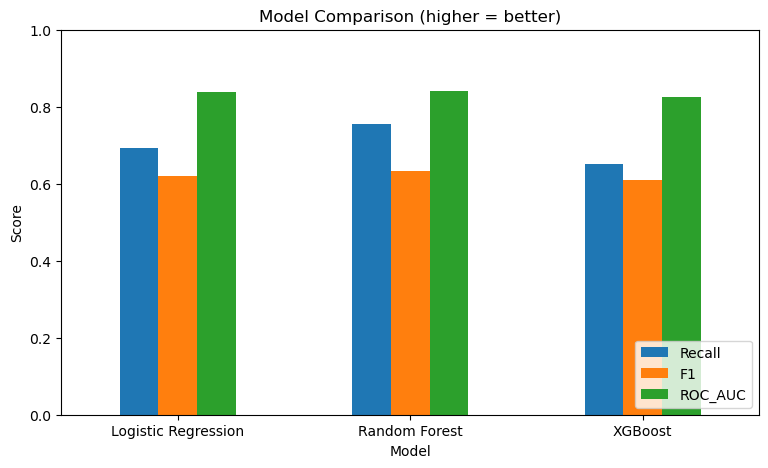

In [44]:
results_df[['Recall', 'F1', 'ROC_AUC']].plot(
    kind='bar', figsize=(9, 5), rot=0
)
plt.title('Model Comparison (higher = better)')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.show()